In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import numpy as np

X1 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X1.npy").astype(np.float32)   
X1 = X1[:, None, :, :]

X2 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X2.npy").astype(np.float32)   
X2 = X2[:, None, :, :]

X3 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X3.npy").astype(np.float32)   
X3 = X3[:, None, :, :]

X4 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X4.npy").astype(np.float32)   
X4 = X4[:, None, :, :]

X5 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X5.npy").astype(np.float32)   
X5 = X5[:, None, :, :]

X6 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X6.npy").astype(np.float32)   
X6 = X6[:, None, :, :]


X_train=np.append(X1, X2,0)
X_train=np.append(X_train, X3,0)
X_train=np.append(X_train, X4,0)
X_train=np.append(X_train, X5,0)
X_train=np.append(X_train, X6,0)

X_train.shape

X1=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X1L.npy")

X2=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X2L.npy")

X3=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X3L.npy")

X4=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X4L.npy")

X5=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X5L.npy")

X6=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X6L.npy")

y_train=np.append(X1, X2,0)
y_train=np.append(y_train, X3,0)
y_train=np.append(y_train, X4,0)
y_train=np.append(y_train, X5,0)
y_train=np.append(y_train, X6,0)

y_train.shape

X7 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X7.npy").astype(np.float32)   
X7 = X7[:, None, :, :]

X8 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X8.npy").astype(np.float32)   
X8 = X8[:, None, :, :]

X_val=np.append(X7, X8,0)

X_val.shape

X7=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X7L.npy")

X8=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X8L.npy")

y_val=np.append(X7, X8,0)

y_val.shape

X9 = np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X9.npy").astype(np.float32)   
X9 = X9[:, None, :, :]

X_test=X9
X_test.shape

X9=np.load(r"C:\Users\Hzaab\Desktop\intern\Data\X9L.npy")
y_test=X9
X_train.shape


(3456, 1, 22, 1001)

In [ ]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

net = EEGNetTorch(
    nb_classes=4,
    Chans=22,
    Samples=1001,
    kernLength=32,
    F1=8,
    D=2, F2=16, dropoutRate=0.5,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

x = torch.randn(2, 1, 22, 1001).float().to(device)
print(net(x).shape)

c:\Users\Hzaab\Desktop\intern\.venv\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(


torch.Size([2, 4])


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import torch

def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)

    print("Y shape:", Y.shape)
    print("pred shape:", pred_labels.shape)
    print("probs shape:", probs.shape)

    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)


In [7]:
batch_size = 16

for epoch in range(10):
    print("\nEpoch ", epoch)

    net.train()
    running_loss = 0.0
    n_seen = 0

    indices = np.random.permutation(len(X_train))

    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i + batch_size]

        inputs = torch.as_tensor(
            X_train[batch_idx],
            dtype=torch.float32,
            device=device
        )

        labels = torch.as_tensor(
            y_train_encoded[batch_idx],
            dtype=torch.long,
            device=device
        )

        optimizer.zero_grad(set_to_none=True)

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        n_seen += inputs.size(0)

    print("Training Loss ", running_loss / n_seen)

    params = ["acc", "auc", "fmeasure"]
    print("Train - ", evaluate(net, X_train, y_train_encoded, params))
    print("Validation - ", evaluate(net, X_val, y_val_encoded, params))

print("Test - ", evaluate(net, X_test, y_test_encoded, params))


Epoch  0
Training Loss  1.393610562991213
Y shape: (3456,)
pred shape: (3456,)
probs shape: (3456, 4)
Train -  [0.3559027777777778, np.float64(0.6078778944115798), 0.324231606823874]
Y shape: (1152,)
pred shape: (1152,)
probs shape: (1152, 4)
Validation -  [0.2838541666666667, np.float64(0.5658797903806584), 0.26364158836144347]

Epoch  1
Training Loss  1.3610675075539835
Y shape: (3456,)
pred shape: (3456,)
probs shape: (3456, 4)
Train -  [0.3958333333333333, np.float64(0.6383453494727367), 0.3708320519181181]
Y shape: (1152,)
pred shape: (1152,)
probs shape: (1152, 4)
Validation -  [0.2821180555555556, np.float64(0.5786102671682097), 0.25695422539353513]

Epoch  2
Training Loss  1.341863152605516
Y shape: (3456,)
pred shape: (3456,)
probs shape: (3456, 4)
Train -  [0.4117476851851852, np.float64(0.6750174035315215), 0.37096660808141785]
Y shape: (1152,)
pred shape: (1152,)
probs shape: (1152, 4)
Validation -  [0.3229166666666667, np.float64(0.6186704282407407), 0.2700726097031867]



[[ 44  44  12  44]
 [  3 132   9   0]
 [ 44  24  51  25]
 [ 22  35   5  82]]


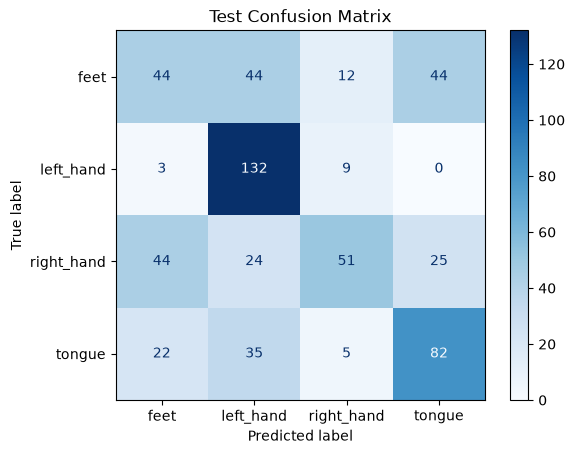

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch
import numpy as np

net.eval()
preds = []

with torch.no_grad():
    for s in range(0, len(X_test), batch_size):
        e = min(s + batch_size, len(X_test))

        inputs = torch.as_tensor(
            X_test[s:e],
            dtype=torch.float32,
            device=device
        )

        outputs = net(inputs)
        batch_preds = outputs.argmax(dim=1)

        preds.append(batch_preds.cpu().numpy())

y_pred = np.concatenate(preds)

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix")
plt.show()